# CIFAR-10 (OpenAI iDDPM): tuning FR's window, $q^*$ and $\eta$

Writes `cache/fr_settings.json` (FR, Bayesian FR and Random in `01_benchmark.ipynb`); runs cached in `cache/parameter_tuning.pt`.

In [1]:
import json, os, sys, time
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from IPython.display import display

ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "src/guidance").exists())
sys.path.insert(0, str(ROOT / "src"))
from models import iddpm as M
from plotting import wsstyle

EXP = ROOT / "experiments/cifar10_openai"
CACHE = EXP / "cache"
CACHE.mkdir(exist_ok=True)

device = os.environ.get("DEVICE") or ("mps" if torch.backends.mps.is_available() else ("cuda" if torch.cuda.is_available() else "cpu"))
config = {
    "n_tuning": 3, "rng_seed": 0,
    "showcase_seeds": [1755, 1527, 209, 1635, 542, 34, 40, 86, 89, 92],
    "excluded_seeds": list(range(140)),   # 01_benchmark's by-eye pool and BM calibration
    # q* in (1/k, 1); eta as a fraction of the base step
    "q_target_grid": [0.8, 0.9], "eta_grid": [0.05, 0.1, 0.2],
}
SCORE = "nl2"

model = M.load(device)
TRAIN, N_STEPS = model["train"], model["n_steps"]
print(f"device={device}, {len(TRAIN)} training images, {N_STEPS} sampling steps, FR defaults: {M.FR_SETTINGS}")

device=mps, 50000 training images, 250 sampling steps, FR defaults: {'k_neighbors': 15, 'ell': 1, 'window_lo': 0.45, 'window_hi': 1.0, 'eta': 0.1, 'q_target': 0.8, 'dirichlet_alpha': 0.8, 'B_bootstrap': 256}


## Tuning seeds

Random memorized and non-memorized seeds from `results/screen_ranked.csv`, excluding seeds 0-139 and the showcase seeds.

In [2]:
TUNING_FILE = CACHE / "parameter_tuning.pt"
signature = {"version": 2, "device": device, "k": M.FR_SETTINGS["k_neighbors"],
             "seed_rule": {k: v for k, v in config.items() if not k.endswith("_grid")}}
tuning = torch.load(TUNING_FILE, map_location="cpu", weights_only=False) if TUNING_FILE.exists() else {}
if tuning.get("signature") != signature:
    tuning = {"signature": signature, "runs": {}}

def run_batch(key, sampler, seeds):
    """Cached results of sampler(seeds) on every seed in `seeds`; missing seeds run as one batch."""
    missing = [s for s in seeds if f"{key}|seed={s}" not in tuning["runs"]]
    if missing:
        start = time.perf_counter()
        for seed, result in zip(missing, sampler(missing)):
            tuning["runs"][f"{key}|seed={seed}"] = result
        torch.save(tuning, TUNING_FILE)
        print(f"{key}: {len(missing)} seeds in {time.perf_counter() - start:.0f}s")
    return {s: tuning["runs"][f"{key}|seed={s}"] for s in seeds}

screen = pd.read_csv(EXP / "results/screen_ranked.csv")
pool = screen[~screen.seed.isin(config["excluded_seeds"] + config["showcase_seeds"])]
rng = np.random.default_rng(config["rng_seed"])
config["memorized_seeds"], config["non_memorized_seeds"] = [
    sorted(int(s) for s in rng.choice(pool.seed[mask].values, config["n_tuning"], replace=False))
    for mask in (pool.nl2 < M.NL2_THRESHOLD, pool.nl2 >= M.NL2_THRESHOLD)]
SEEDS = config["memorized_seeds"] + config["non_memorized_seeds"]
assert not set(SEEDS) & set(config["showcase_seeds"])
print(f"tuning seeds: memorized {config['memorized_seeds']}, non-memorized {config['non_memorized_seeds']}")

tuning seeds: memorized [530, 895, 1234], non-memorized [267, 740, 1575]


## 1. FR along the unguided trajectory

`lock_in`: progress after which the nearest training image of $\hat x_0$ stops changing. `q_saturates`: first progress with untempered $q_{\max} \ge 0.99$.

In [3]:
if "traces" not in tuning:
    start = time.perf_counter()
    endpoints, tuning["traces"], tuning["snapshots"] = M.fr_traces(model, config["memorized_seeds"])
    tuning["trace_endpoints"] = torch.cat([e["x"] for e in endpoints])
    torch.save(tuning, TUNING_FILE)
    print(f"traces: {time.perf_counter() - start:.0f}s")
traces, snapshots = tuning["traces"], tuning["snapshots"]
progress = np.arange(1, N_STEPS + 1) / N_STEPS

rows = []
for s, (seed, end) in enumerate(zip(config["memorized_seeds"], M.memorization(model, tuning["trace_endpoints"]))):
    nn = traces["nn_idx"][s]
    changed = np.flatnonzero(nn != nn[-1])
    lock = changed[-1] + 1 if len(changed) else 0
    saturated = np.flatnonzero(traces["q_max"][s] >= 0.99)
    rows.append({"seed": seed, SCORE: end[SCORE], "memorized": end["is_memorized"], "nn_idx": int(nn[-1]),
                 "lock_in": progress[lock], "x0hat_ratio_at_lock_in": traces["ratio"][s, lock],
                 "q_saturates": progress[saturated[0]] if len(saturated) else np.nan})
lock_in = pd.DataFrame(rows).set_index("seed")
display(lock_in.round(3))

,nl2,memorized,nn_idx,lock_in,x0hat_ratio_at_lock_in,q_saturates
seed,,,,,,
530,1.298,True,3259,0.492,0.992,0.020
895,1.308,True,9881,0.528,0.999,0.004
1234,1.400,True,32234,0.444,0.998,0.004


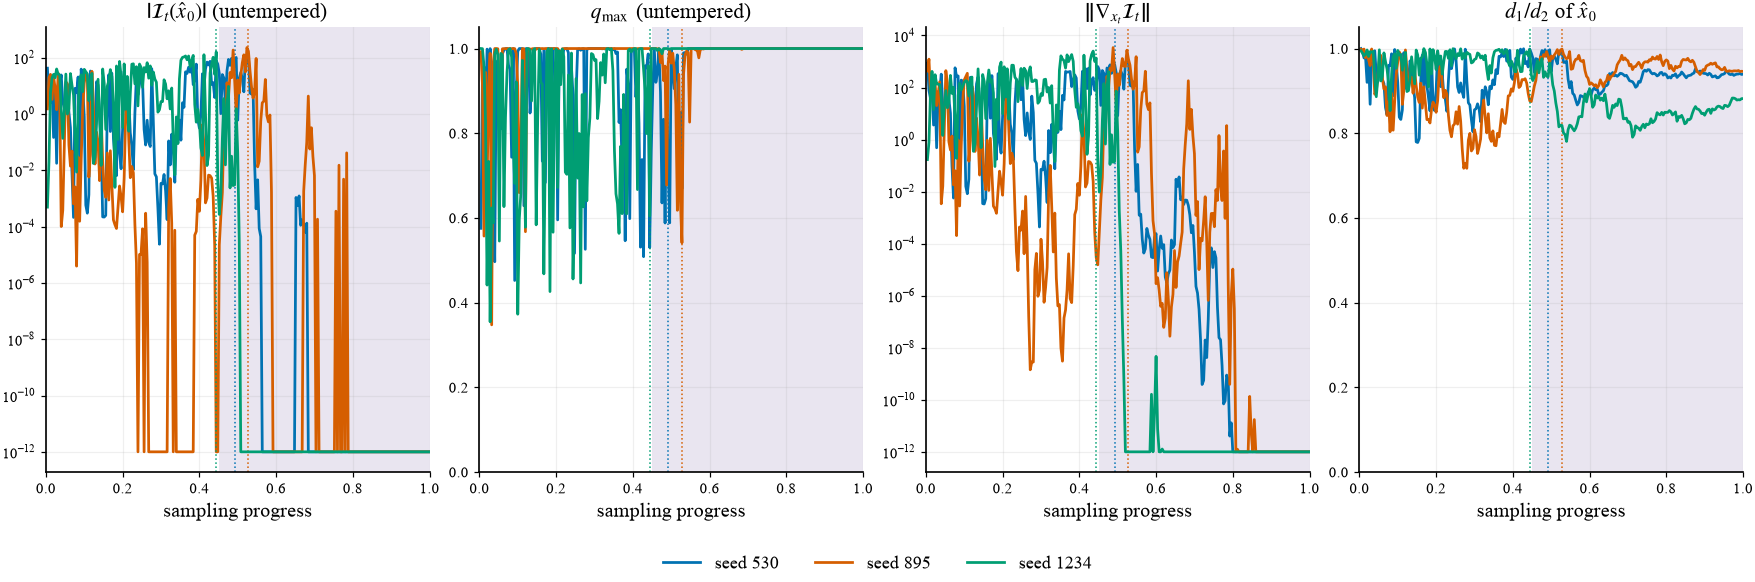

shaded: the current default window (0.45, 1.0); dotted: each seed's lock-in


In [4]:
wsstyle.paper_style()
palette = [wsstyle.OKABE_ITO[c] for c in ("blue", "vermilion", "green", "orange", "purple")]
default_window = (M.FR_SETTINGS["window_lo"], M.FR_SETTINGS["window_hi"])

fig, ax = plt.subplots(1, 4, figsize=(wsstyle.FULL_WIDTH, 0.3 * wsstyle.FULL_WIDTH), constrained_layout=True)
panels = [("I", r"$|\mathcal{I}_t(\hat x_0)|$ (untempered)", "log"), ("q_max", r"$q_{\max}$ (untempered)", "linear"),
          ("grad_norm", r"$\|\nabla_{x_t}\mathcal{I}_t\|$", "log"), ("ratio", r"$d_1/d_2$ of $\hat x_0$", "linear")]
for a, (key, label, scale) in zip(ax, panels):
    a.axvspan(*default_window, color=wsstyle.C["field"], alpha=0.16, lw=0, zorder=0)
    for s, (seed, c) in enumerate(zip(config["memorized_seeds"], palette)):
        values = np.abs(traces[key][s]) if scale == "log" else traces[key][s]
        a.plot(progress, np.maximum(values, 1e-12) if scale == "log" else values, lw=1.8, color=c, label=f"seed {seed}")
        a.axvline(lock_in.loc[seed, "lock_in"], color=c, lw=1.0, ls=":")
    a.set_yscale(scale)
    a.set_xlim(0, 1)
    a.set_xlabel("sampling progress")
    a.set_title(label)
    wsstyle.grid_on(a)
ax[1].set_ylim(0, 1.05); ax[3].set_ylim(0, 1.05)
fig.legend(*ax[0].get_legend_handles_labels(), loc="lower center", ncol=5, bbox_to_anchor=(0.5, -0.12), frameon=False)
plt.show()
print(f"shaded: the current default window {default_window}; dotted: each seed's lock-in")

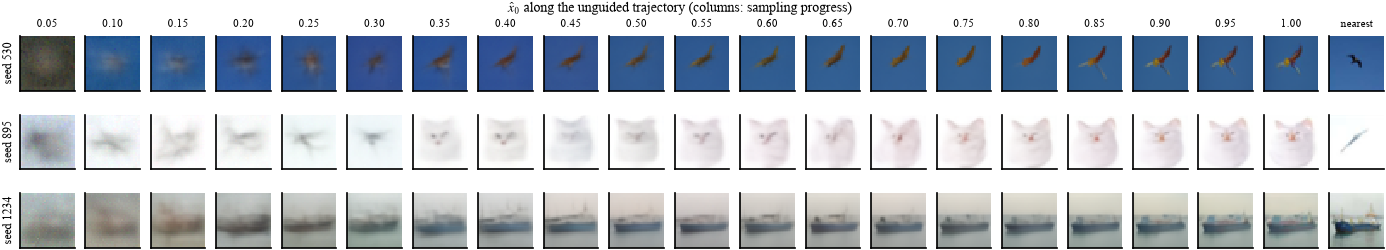

In [5]:
def to_img(x):
    return ((x.reshape(3, 32, 32) + 1) / 2).clamp(0, 1).permute(1, 2, 0).numpy()

n_seeds, n_snaps = snapshots.shape[:2]
fig, axes = plt.subplots(n_seeds, n_snaps + 1, figsize=(wsstyle.FULL_WIDTH, wsstyle.FULL_WIDTH * n_seeds / (n_snaps + 1) * 1.15))
for s, seed in enumerate(config["memorized_seeds"]):
    for j in range(n_snaps + 1):
        a = axes[s, j]
        a.imshow(to_img(snapshots[s, j] if j < n_snaps else TRAIN[lock_in.loc[seed, "nn_idx"]].cpu()), interpolation="nearest")
        a.set_xticks([]); a.set_yticks([])
        if s == 0:
            a.set_title(f"{traces['snapshot_progress'][j]:.2f}" if j < n_snaps else "nearest", fontsize=7)
    axes[s, 0].set_ylabel(f"seed {seed}", fontsize=8)
fig.suptitle(r"$\hat x_0$ along the unguided trajectory (columns: sampling progress)", fontsize=9)
plt.show()

## 2. Choose the window

Set `WINDOW` by hand, with `lo` before the earliest lock-in.

In [6]:
WINDOW = (0.1, 1.0)   # sampling progress
assert WINDOW is not None, "choose WINDOW from the trajectory figures above, then run the rest of the notebook"
print(f"window {WINDOW}: guidance on {int(round((WINDOW[1] - WINDOW[0]) * N_STEPS))} of {N_STEPS} steps")

window (0.1, 1.0): guidance on 225 of 250 steps


## 3. Grid over $q^*$ and $\eta$

`escaped`: memorized seeds no longer memorized. `displacement`: $\lVert x - x_{\text{unguided}}\rVert / \lVert x_{\text{unguided}}\rVert$.

In [7]:
def settings_for(q_target, eta):
    return {**M.FR_SETTINGS, "window_lo": WINDOW[0], "window_hi": WINDOW[1], "q_target": q_target, "eta": eta}

def key_of(setting):
    return "fr|" + "|".join(f"{k}={setting[k]}" for k in ("window_lo", "window_hi", "q_target", "eta", "k_neighbors", "ell"))

unguided = run_batch("unguided", lambda seeds: M.unguided(model, seeds), SEEDS)
GRID = [settings_for(q, eta) for q in config["q_target_grid"] for eta in config["eta_grid"]]
rows = []
for setting in GRID:
    out = run_batch(key_of(setting), lambda seeds: M.fr(model, seeds, settings=setting), SEEDS)
    for seed in SEEDS:
        x, x_base = out[seed]["x"], unguided[seed]["x"]
        rows.append({"q_target": setting["q_target"], "eta": setting["eta"], "seed": seed,
                     "group": "memorized" if seed in config["memorized_seeds"] else "non-memorized",
                     **M.memorization(model, x)[0], "displacement": ((x - x_base).norm() / x_base.norm()).item(),
                     "active_steps": int(out[seed]["active"].sum())})
grid = pd.DataFrame(rows)

escaped  nl2_memorized  displacement_memorized  \
q_target eta                                                    
0.8      0.05        3          1.619                   0.459   
         0.10        3          1.764                   0.826   
         0.20        3          1.802                   1.467   
0.9      0.05        2          1.556                   0.492   
         0.10        3          1.684                   0.731   
         0.20        3          1.665                   1.666   

               displacement_non_memorized  non_memorized_now_memorized  
q_target eta                                                            
0.8      0.05                       1.118                            0  
         0.10                       1.331                            0  
         0.20                       2.099                            0  
0.9      0.05                       0.675                            0  
         0.10                       1.443                            0  
         0.20                       2.869                            0

seed            530    895    1234
q_target eta                      
0.8      0.05  1.536  1.651  1.670
         0.10  1.788  1.710  1.794
         0.20  1.839  1.799  1.769
0.9      0.05  1.366  1.646  1.657
         0.10  1.762  1.623  1.667
         0.20  1.525  1.803  1.668

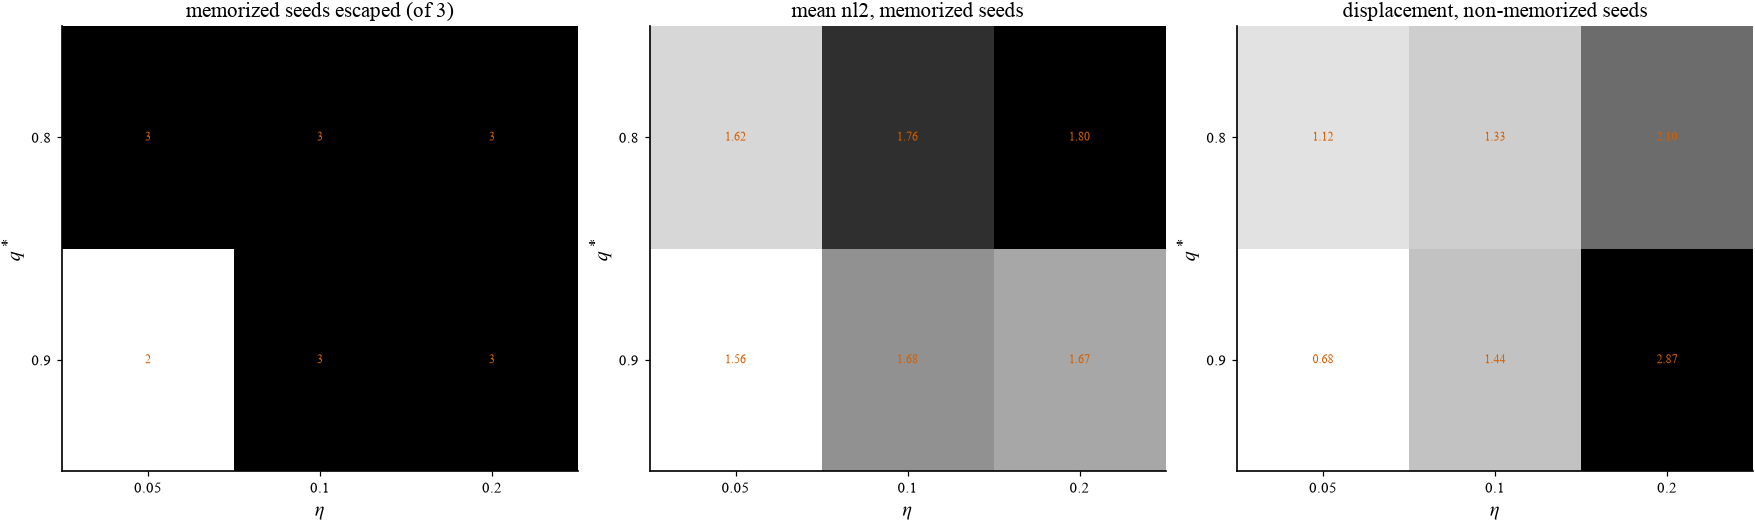

In [8]:
by = ["q_target", "eta"]
mem, non = grid[grid.group == "memorized"].groupby(by), grid[grid.group == "non-memorized"].groupby(by)
summary = pd.DataFrame({"escaped": mem.is_memorized.apply(lambda m: int((~m).sum())),
                        f"{SCORE}_memorized": mem[SCORE].mean(),
                        "displacement_memorized": mem.displacement.mean(),
                        "displacement_non_memorized": non.displacement.mean(),
                        "non_memorized_now_memorized": non.is_memorized.sum()})
display(summary.round(3))
display(grid[grid.group == "memorized"].pivot_table(index=by, columns="seed", values=SCORE, sort=False).round(3))

fig, ax = plt.subplots(1, 3, figsize=(wsstyle.FULL_WIDTH, 0.3 * wsstyle.FULL_WIDTH), constrained_layout=True)
for a, (column, title, fmt) in zip(ax, [("escaped", "memorized seeds escaped (of 3)", "{:.0f}"),
                                        (f"{SCORE}_memorized", f"mean {SCORE}, memorized seeds", "{:.2f}"),
                                        ("displacement_non_memorized", "displacement, non-memorized seeds", "{:.2f}")]):
    table = summary[column].unstack("eta")
    a.imshow(table.values, cmap="Greys", aspect="auto")
    for (i, j), v in np.ndenumerate(table.values):
        a.text(j, i, fmt.format(v), ha="center", va="center", color=wsstyle.OKABE_ITO["vermilion"], fontsize=8)
    a.set_xticks(range(table.shape[1]), [f"{v:g}" for v in table.columns]); a.set_xlabel(r"$\eta$")
    a.set_yticks(range(table.shape[0]), [f"{v:g}" for v in table.index]); a.set_ylabel(r"$q^*$")
    a.set_title(title)
plt.show()

### Every configuration, side by side

Red score: still memorized. Displayed only.

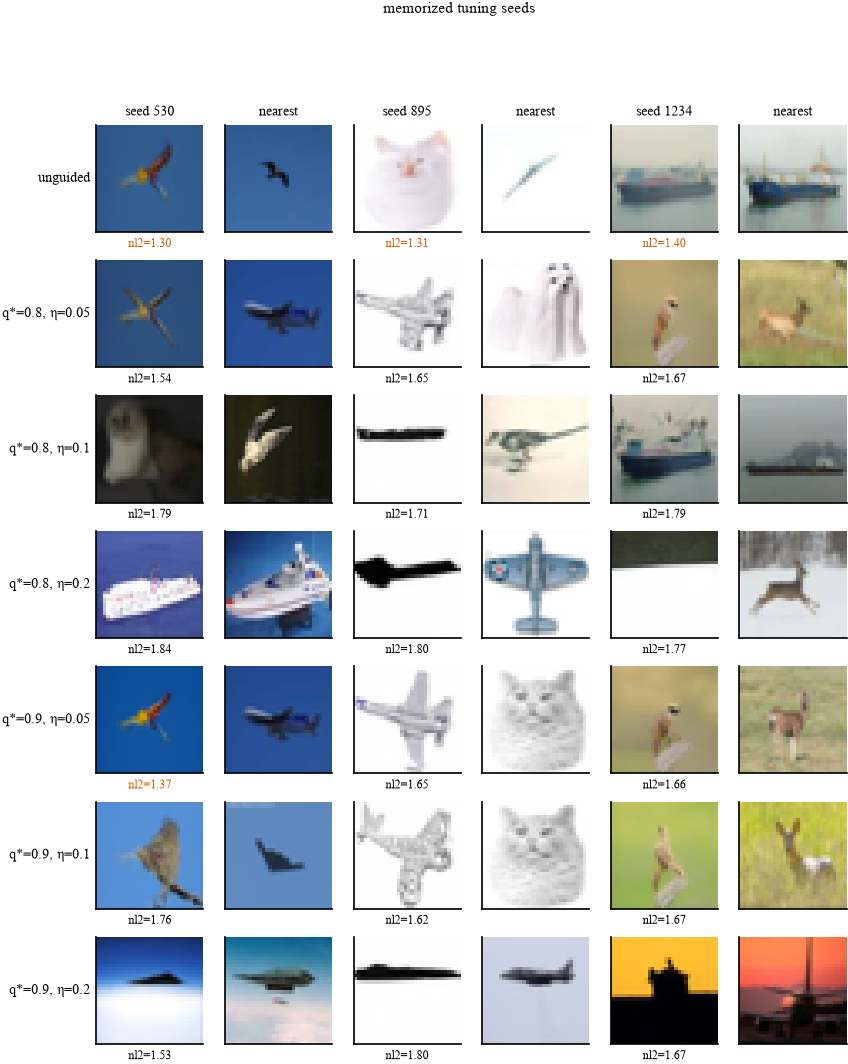

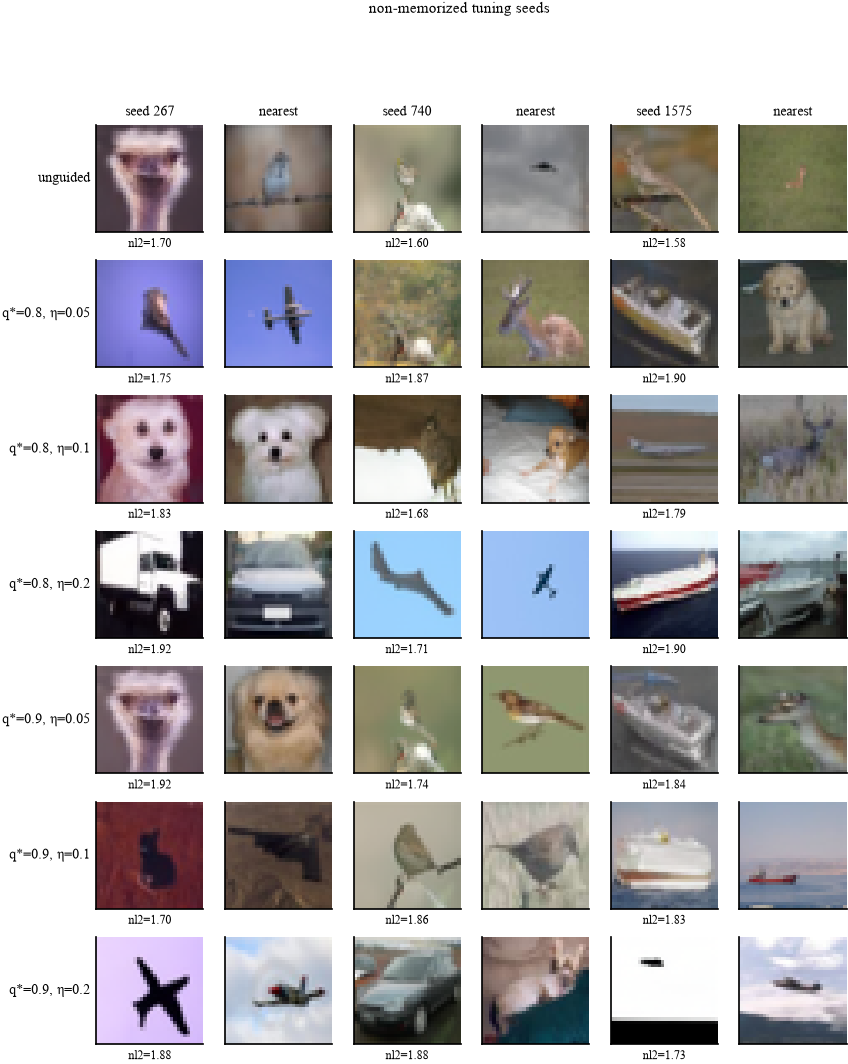

In [9]:
def comparison(seeds, title):
    rows = [("unguided", "unguided")] + [(f"q*={s['q_target']:g}, η={s['eta']:g}", key_of(s)) for s in GRID]
    tile = 0.075 * wsstyle.FULL_WIDTH
    fig, axes = plt.subplots(len(rows), 2 * len(seeds), figsize=(2 * len(seeds) * tile + 1.6, len(rows) * tile * 1.3),
                             squeeze=False)
    for i, (label, key) in enumerate(rows):
        for j, seed in enumerate(seeds):
            x = tuning["runs"][f"{key}|seed={seed}"]["x"]
            mem = M.memorization(model, x)[0]
            for a, image in zip(axes[i, 2 * j:2 * j + 2], (x, TRAIN[mem["nn_idx"]].cpu())):
                a.imshow(to_img(image), interpolation="nearest")
                a.set_xticks([]); a.set_yticks([])
            axes[i, 2 * j].set_xlabel(f"{SCORE}={mem[SCORE]:.2f}", fontsize=8,
                                      color=wsstyle.OKABE_ITO["vermilion"] if mem["is_memorized"] else "black")
            if i == 0:
                axes[i, 2 * j].set_title(f"seed {seed}", fontsize=9)
                axes[i, 2 * j + 1].set_title("nearest", fontsize=9)
        axes[i, 0].set_ylabel(label, rotation=0, ha="right", va="center", fontsize=9)
    fig.suptitle(title, fontsize=10)
    plt.show()

comparison(config["memorized_seeds"], "memorized tuning seeds")
comparison(config["non_memorized_seeds"], "non-memorized tuning seeds")

## 4. Operating point

Rule: most memorized seeds escaped, then lowest non-memorized displacement, then smaller $\eta$. `CHOSEN` overrides it (by eye: $\eta \ge 0.2$ collapses to flat silhouettes).

In [10]:
CHOSEN = (0.9, 0.1)   # None applies the rule
ranked = summary.reset_index().sort_values(["escaped", "displacement_non_memorized", "eta"], ascending=[False, True, True])
q_target, eta = CHOSEN if CHOSEN is not None else (ranked.iloc[0].q_target, ranked.iloc[0].eta)
FR_TUNED = settings_for(float(q_target), float(eta))
chosen_row = summary.loc[(FR_TUNED["q_target"], FR_TUNED["eta"])]
(CACHE / "fr_settings.json").write_text(json.dumps(
    {**FR_TUNED, "chosen_by": "eye" if CHOSEN is not None else "rule",
     "tuned_on": {"memorized_seeds": config["memorized_seeds"], "non_memorized_seeds": config["non_memorized_seeds"]}}, indent=1))
display(ranked.round(3))
print(f"FR: window {WINDOW}, q*={FR_TUNED['q_target']:g}, eta={FR_TUNED['eta']:g}, chosen by {'eye' if CHOSEN is not None else 'rule'} "
      f"({int(chosen_row.escaped)}/{len(config['memorized_seeds'])} escaped) -> {(CACHE / 'fr_settings.json').relative_to(EXP)}")

,q_target,eta,escaped,nl2_memorized,displacement_memorized,displacement_non_memorized,non_memorized_now_memorized
0,0.8,0.05,3,1.619,0.459,1.118,0
1,0.8,0.10,3,1.764,0.826,1.331,0
4,0.9,0.10,3,1.684,0.731,1.443,0
2,0.8,0.20,3,1.802,1.467,2.099,0
5,0.9,0.20,3,1.665,1.666,2.869,0
3,0.9,0.05,2,1.556,0.492,0.675,0


FR: window (0.1, 1.0), q*=0.9, eta=0.1, chosen by eye (3/3 escaped) -> cache/fr_settings.json
